<a href="https://colab.research.google.com/github/SUDEEPZ-RAM/Classification-of-speech-categories-from-1-bit-quantized-signals/blob/main/Classical%20Models/mlORIGINAL_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
numeric = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features_original_numeric.csv"
)

command = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features_original_command.csv"
)

read = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features_original_read.csv"
)

conversation = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features_original_conversation.csv"
)

print("Numeric:", numeric.shape)
print("Command:", command.shape)
print("Read:", read.shape)
print("Conversation:", conversation.shape)

Numeric: (3000, 23)
Command: (3000, 23)
Read: (3000, 23)
Conversation: (3000, 23)


In [ ]:
numeric["speech_type"] = "numeric"
command["speech_type"] = "command"
read["speech_type"] = "read"
conversation["speech_type"] = "conversational"

In [ ]:
df = pd.concat(
    [
        numeric,
        command,
        read,
        conversation
    ],
    ignore_index=True
)

print(df.shape)

print(df["speech_type"].value_counts())

(12000, 25)
speech_type
numeric           3000
command           3000
read              3000
conversational    3000
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()

df["target"] = le.fit_transform(
    df["speech_type"]
)

print(
    dict(
        zip(
            le.classes_,
            range(len(le.classes_))
        )
    )
)

{'command': 0, 'conversational': 1, 'numeric': 2, 'read': 3}


In [ ]:
remove_cols = []

for col in [
    "filepath",
    "filename",
    "speaker",
    "session",
    "command",
    "digit",
    "label",
    "speech_type",
    "target"
]:

    if col in df.columns:
        remove_cols.append(col)

X = df.drop(
    columns=remove_cols
)

y = df["target"]

print("Features Shape:", X.shape)

Features Shape: (12000, 20)


In [ ]:
# First split: 80 train, 20 temp

X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

# Split temp into validation and test

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (9600, 20)
Validation: (1200, 20)
Test: (1200, 20)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)

**RANDOM FOREST**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
rf_train_pred = rf.predict(X_train)

rf_val_pred = rf.predict(X_val)

rf_test_pred = rf.predict(X_test)

rf_train_acc = accuracy_score(
    y_train,
    rf_train_pred
)

rf_val_acc = accuracy_score(
    y_val,
    rf_val_pred
)

rf_test_acc = accuracy_score(
    y_test,
    rf_test_pred
)

print("Train Accuracy:", rf_train_acc)
print("Validation Accuracy:", rf_val_acc)
print("Test Accuracy:", rf_test_acc)

Train Accuracy: 1.0
Validation Accuracy: 0.7875
Test Accuracy: 0.785


In [ ]:
print(
    classification_report(
        y_test,
        rf_test_pred,
        target_names=le.classes_
    )
)

                precision    recall  f1-score   support

       command       0.71      0.70      0.70       300
conversational       0.78      0.82      0.80       300
       numeric       0.93      0.91      0.92       300
          read       0.72      0.72      0.72       300

      accuracy                           0.79      1200
     macro avg       0.79      0.78      0.79      1200
  weighted avg       0.79      0.79      0.79      1200



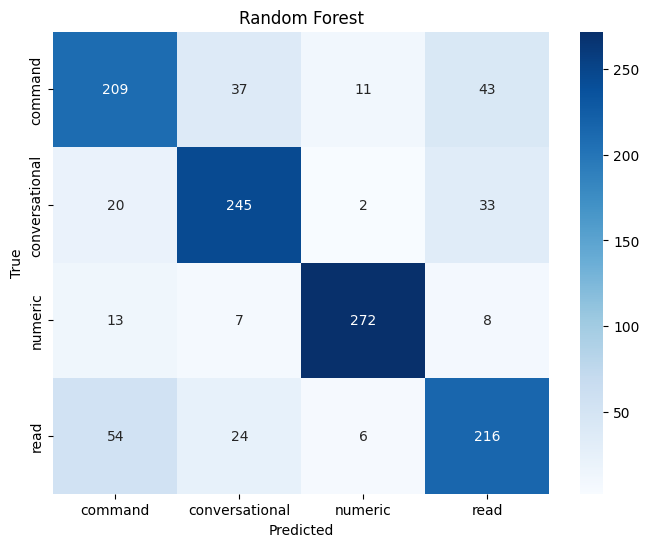

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_test_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest")

plt.show()

**LOGISTIC REGRESSION**

In [ ]:
lr = LogisticRegression(
    max_iter=5000
)

lr.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=5000)

In [ ]:
lr_train_pred = lr.predict(
    X_train_scaled
)

lr_val_pred = lr.predict(
    X_val_scaled
)

lr_test_pred = lr.predict(
    X_test_scaled
)

lr_train_acc = accuracy_score(
    y_train,
    lr_train_pred
)

lr_val_acc = accuracy_score(
    y_val,
    lr_val_pred
)

lr_test_acc = accuracy_score(
    y_test,
    lr_test_pred
)

print("Train Accuracy:", lr_train_acc)
print("Validation Accuracy:", lr_val_acc)
print("Test Accuracy:", lr_test_acc)

Train Accuracy: 0.6738541666666666
Validation Accuracy: 0.6541666666666667
Test Accuracy: 0.6658333333333334


In [ ]:
print(
    classification_report(
        y_test,
        lr_test_pred,
        target_names=le.classes_
    )
)

                precision    recall  f1-score   support

       command       0.50      0.53      0.52       300
conversational       0.71      0.73      0.72       300
       numeric       0.83      0.81      0.82       300
          read       0.63      0.59      0.61       300

      accuracy                           0.67      1200
     macro avg       0.67      0.67      0.67      1200
  weighted avg       0.67      0.67      0.67      1200



In [ ]:
svm = SVC()

svm.fit(
    X_train_scaled,
    y_train
)

SVC()

In [ ]:
svm_train_pred = svm.predict(
    X_train_scaled
)

svm_val_pred = svm.predict(
    X_val_scaled
)

svm_test_pred = svm.predict(
    X_test_scaled
)

svm_train_acc = accuracy_score(
    y_train,
    svm_train_pred
)

svm_val_acc = accuracy_score(
    y_val,
    svm_val_pred
)

svm_test_acc = accuracy_score(
    y_test,
    svm_test_pred
)

print("Train Accuracy:", svm_train_acc)
print("Validation Accuracy:", svm_val_acc)
print("Test Accuracy:", svm_test_acc)

Train Accuracy: 0.7863541666666667
Validation Accuracy: 0.7666666666666667
Test Accuracy: 0.7466666666666667


In [ ]:
print(
    classification_report(
        y_test,
        svm_test_pred,
        target_names=le.classes_
    )
)

                precision    recall  f1-score   support

       command       0.65      0.66      0.65       300
conversational       0.78      0.76      0.77       300
       numeric       0.90      0.89      0.89       300
          read       0.67      0.68      0.68       300

      accuracy                           0.75      1200
     macro avg       0.75      0.75      0.75      1200
  weighted avg       0.75      0.75      0.75      1200



In [ ]:
results = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Logistic Regression",
        "SVM"
    ],

    "Train Accuracy": [
        rf_train_acc,
        lr_train_acc,
        svm_train_acc
    ],

    "Validation Accuracy": [
        rf_val_acc,
        lr_val_acc,
        svm_val_acc
    ],

    "Test Accuracy": [
        rf_test_acc,
        lr_test_acc,
        svm_test_acc
    ]
})

results

,Model,Train Accuracy,Validation Accuracy,Test Accuracy
0,Random Forest,1.000000,0.787500,0.785000
1,Logistic Regression,0.673854,0.654167,0.665833
2,SVM,0.786354,0.766667,0.746667


In [ ]:
X.columns

Index(['mean_zcr', 'std_zcr', 'min_zcr', 'max_zcr', 'mean_pos_run',
       'std_pos_run', 'max_pos_run', 'mean_neg_run', 'std_neg_run',
       'max_neg_run', 'mean_autocorr_peak', 'std_autocorr_peak',
       'mean_amdf_min', 'std_amdf_min', 'mean_hnr', 'std_hnr',
       'mean_rhythm_change', 'std_rhythm_change', 'active_frame_ratio',
       'longest_active_region'],
      dtype='object')

In [ ]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
xgb = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='multi:softmax',

    num_class=4,

    random_state=42,

    eval_metric='mlogloss'
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=4, ...)

In [ ]:
xgb_train_pred = xgb.predict(X_train)

xgb_val_pred = xgb.predict(X_val)

xgb_test_pred = xgb.predict(X_test)

xgb_train_acc = accuracy_score(
    y_train,
    xgb_train_pred
)

xgb_val_acc = accuracy_score(
    y_val,
    xgb_val_pred
)

xgb_test_acc = accuracy_score(
    y_test,
    xgb_test_pred
)

print("Train Accuracy:", xgb_train_acc)
print("Validation Accuracy:", xgb_val_acc)
print("Test Accuracy:", xgb_test_acc)

Train Accuracy: 0.96875
Validation Accuracy: 0.8066666666666666
Test Accuracy: 0.8066666666666666


In [ ]:
print(
    classification_report(
        y_test,
        xgb_test_pred,
        target_names=le.classes_
    )
)

                precision    recall  f1-score   support

       command       0.75      0.69      0.72       300
conversational       0.81      0.86      0.83       300
       numeric       0.92      0.93      0.93       300
          read       0.74      0.75      0.74       300

      accuracy                           0.81      1200
     macro avg       0.81      0.81      0.81      1200
  weighted avg       0.81      0.81      0.81      1200



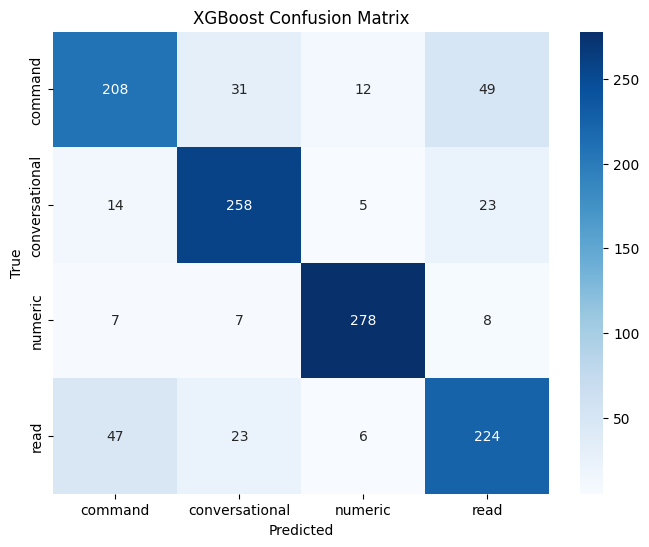

In [ ]:
cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [ ]:
import numpy as np

cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

class_acc = cm.diagonal() / cm.sum(axis=1)

for cls, acc in zip(
    le.classes_,
    class_acc
):
    print(
        f"{cls:15s} : {acc*100:.2f}%"
    )

command         : 69.33%
conversational  : 86.00%
numeric         : 92.67%
read            : 74.67%


In [ ]:
results.loc[len(results)] = [

    "XGBoost",

    xgb_train_acc,

    xgb_val_acc,

    xgb_test_acc
]

results

,Model,Train Accuracy,Validation Accuracy,Test Accuracy
0,Random Forest,1.000000,0.787500,0.785000
1,Logistic Regression,0.673854,0.654167,0.665833
2,SVM,0.786354,0.766667,0.746667
3,XGBoost,0.968750,0.806667,0.806667


In [ ]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
9,max_neg_run,0.104357
11,std_autocorr_peak,0.100454
13,std_amdf_min,0.097302
6,max_pos_run,0.087667
12,mean_amdf_min,0.068563
19,longest_active_region,0.054923
16,mean_rhythm_change,0.047413
7,mean_neg_run,0.046999
3,max_zcr,0.038892
0,mean_zcr,0.038459


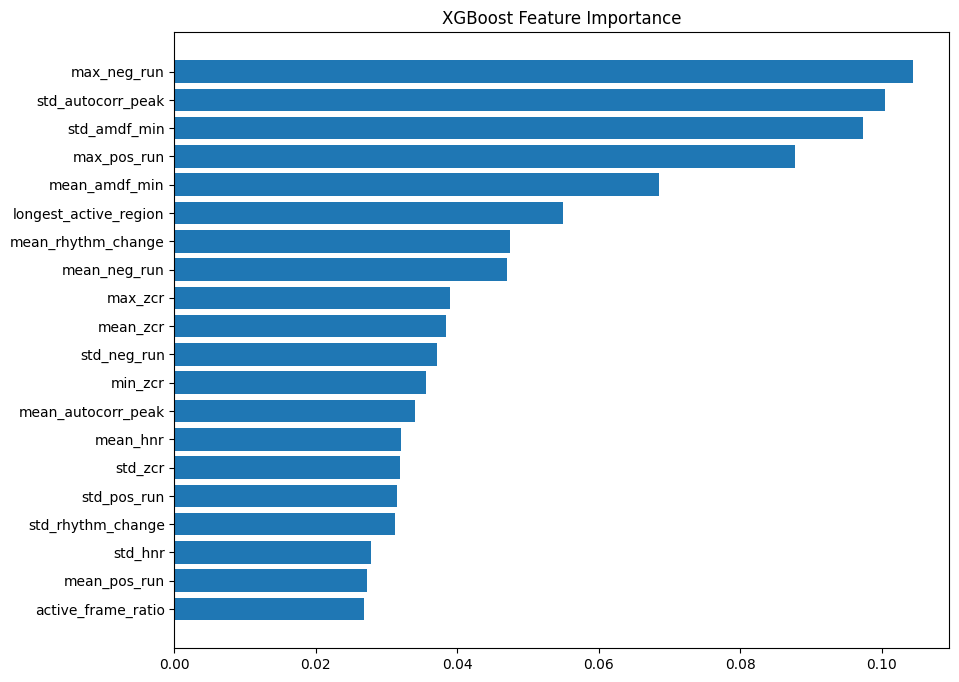

In [ ]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "XGBoost Feature Importance"
)

plt.show()

Best Model Evaluation
Accuracy           : 0.8067
Precision (Macro)  : 0.8057
Recall (Macro)     : 0.8067
F1 Score           : 0.8057
ROC-AUC            : 0.9517
Macro F1           : 0.8057
Equal Error Rate   : 0.1089


<Figure size 600x500 with 0 Axes>

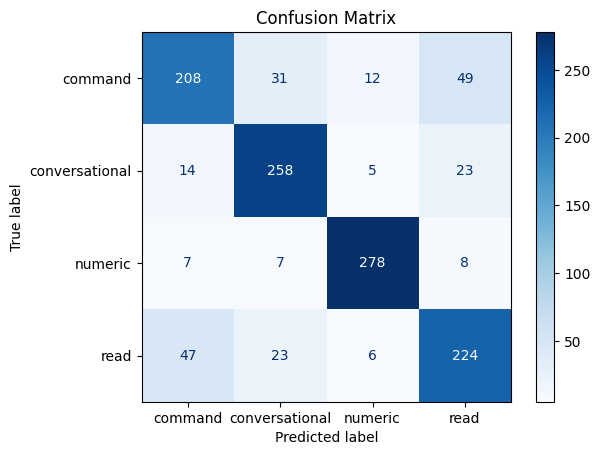

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Predictions
# -----------------------------
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)

# -----------------------------
# Metrics
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

macro_f1 = f1

# -----------------------------
# ROC-AUC
# -----------------------------
classes = np.unique(y_test)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class="ovr",
    average="macro"
)

# -----------------------------
# Equal Error Rate (EER)
# -----------------------------
eer_list = []

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    fnr = 1 - tpr

    idx = np.nanargmin(np.abs(fpr - fnr))

    eer = (fpr[idx] + fnr[idx]) / 2

    eer_list.append(eer)

eer = np.mean(eer_list)

# -----------------------------
# Print Metrics
# -----------------------------
print("="*45)
print("Best Model Evaluation")
print("="*45)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (Macro)  : {precision:.4f}")
print(f"Recall (Macro)     : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"Equal Error Rate   : {eer:.4f}")

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()